In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import glob
import os
import string
# import arviz as az
from scipy.integrate import trapezoid as trapz

from scipy.integrate import cumulative_trapezoid as cumtrapz
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['font.family']='Arial'

bar_width=0.25
plt.rc('axes', labelsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12)
alphsize=12
alpha=0.4
padsize=15
set_dpi=600
fig_dir = "Figures"
os.makedirs(fig_dir, exist_ok=True)

region_name = ['Korea']
reg_color = ['blue']
season_color = ['skyblue', 'darkkhaki', 'violet']

# Figure 1

In [ ]:
flu_1617 = pd.read_excel('Results/influenza_data.xlsx', sheet_name='flu_1617')
flu_1718 = pd.read_excel('Results/influenza_data.xlsx', sheet_name='flu_1718')
flu_2223 = pd.read_excel('Results/influenza_data.xlsx', sheet_name='flu_2223')

pos_1617 = pd.read_excel('Results/influenza_data.xlsx', sheet_name='pos_1617')
pos_1718 = pd.read_excel('Results/influenza_data.xlsx', sheet_name='pos_1718')
pos_2223 = pd.read_excel('Results/influenza_data.xlsx', sheet_name='pos_2223')

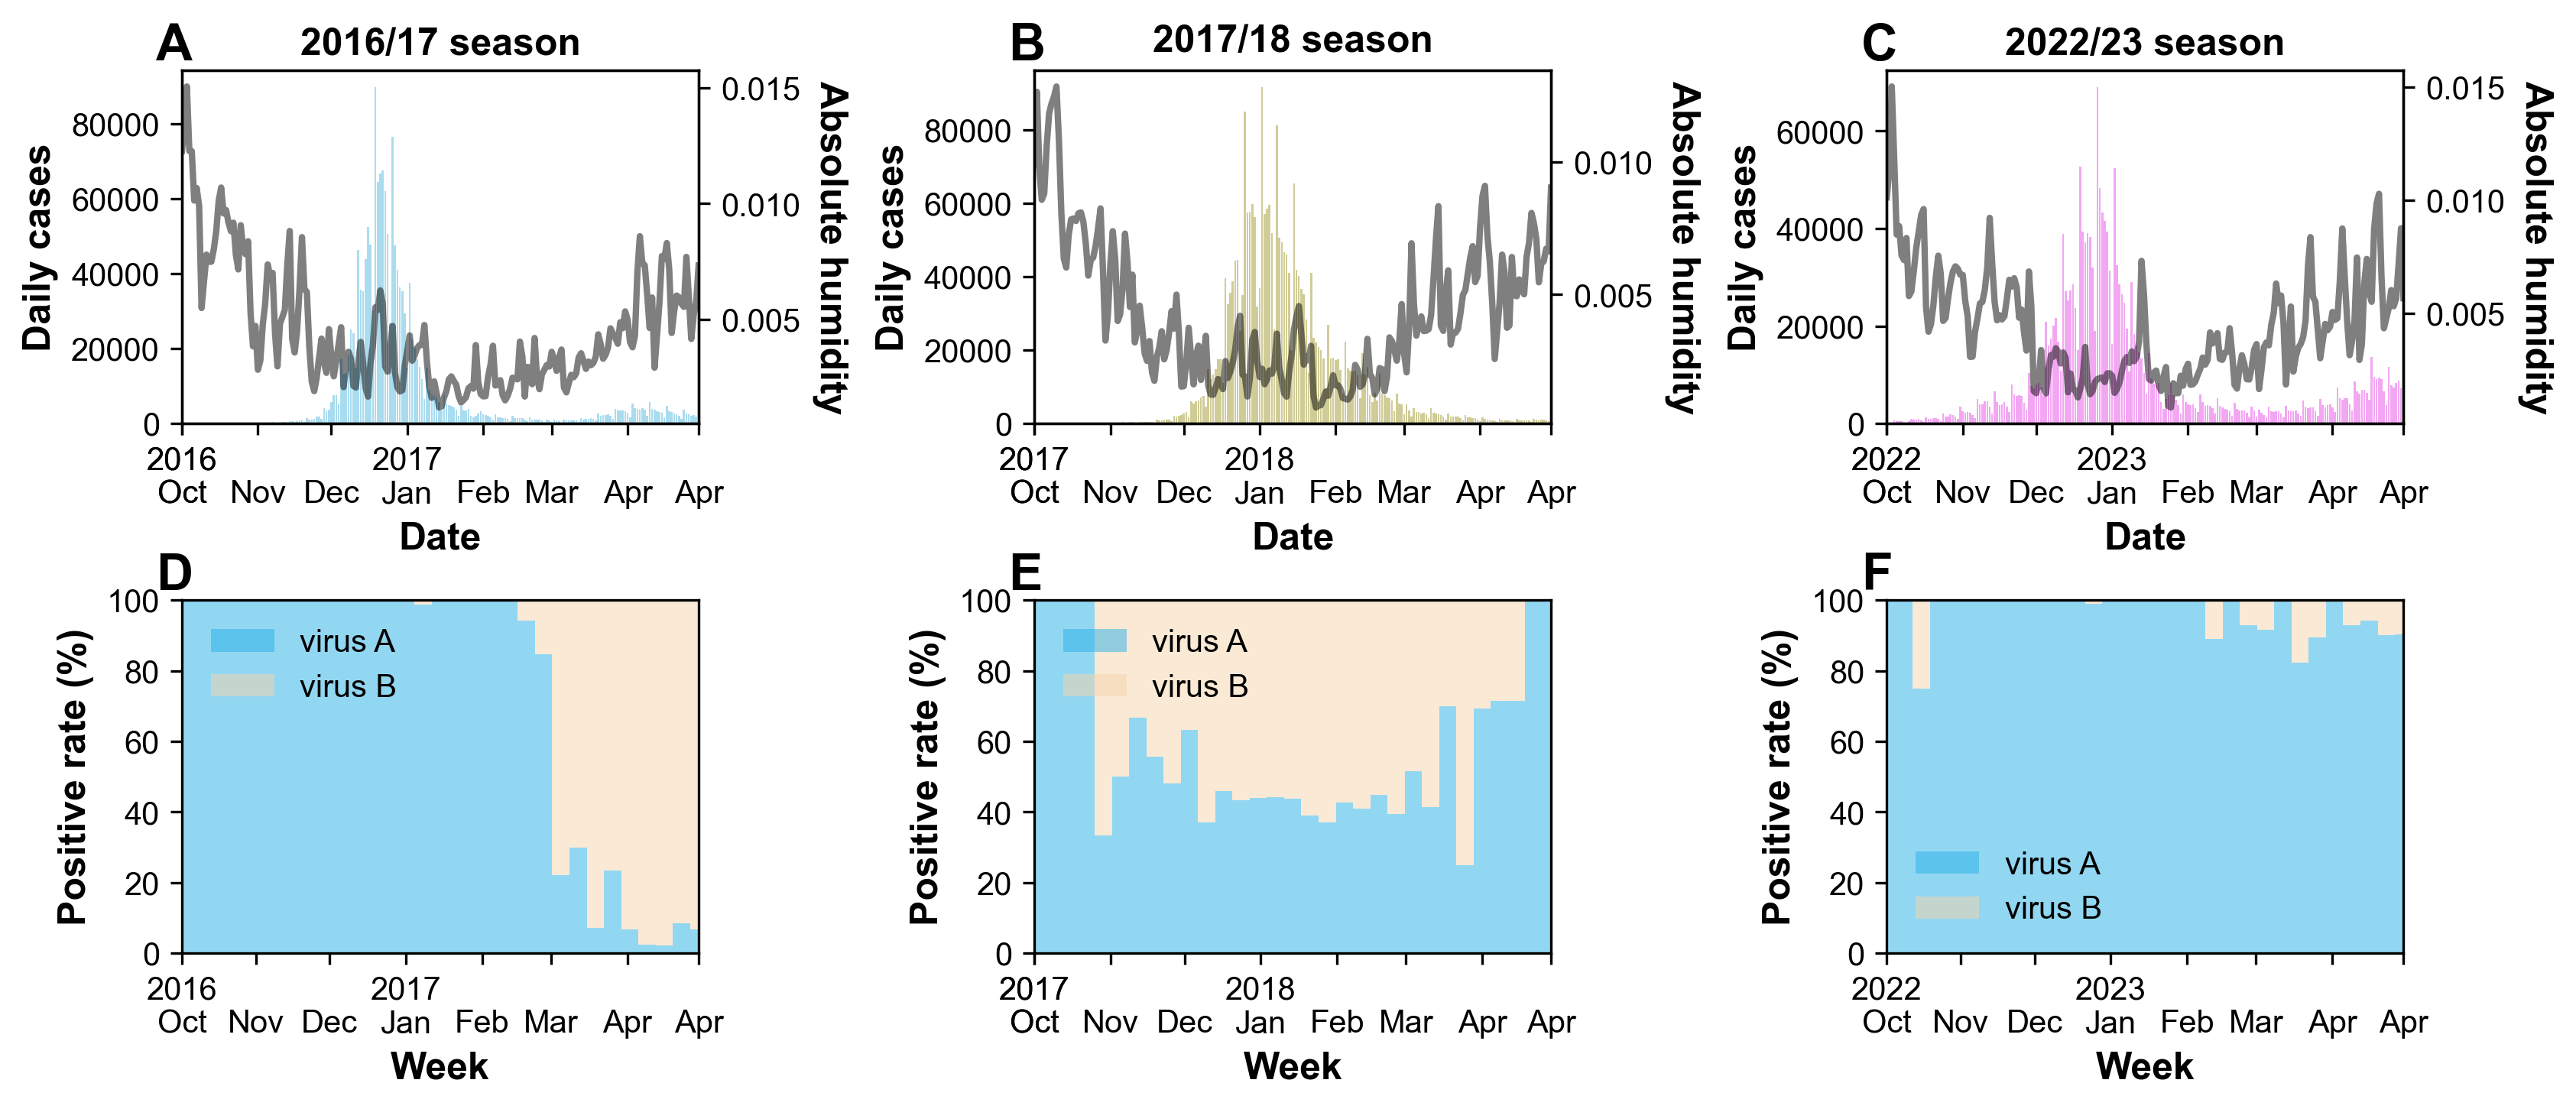

In [4]:
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

def make_formatter(first_month_dict):
    def year_month_formatter(x, pos=None):
        dt = mdates.num2date(x)
        year = dt.year
        month = dt.month
        if month == first_month_dict.get(year, None):
            return f"{year}\n{dt.strftime('%b')}"
        else:
            return dt.strftime('\n%b')
    return year_month_formatter

# A 비율 적용한 시각화
fig, axes = plt.subplots(2,3, figsize=(12.5,5), dpi=300)

ax=axes[0,0]
ax.bar(flu_1617['Date'], flu_1617['Case'], color=season_color[0], label='Korea', linewidth=2, alpha=0.7) 
ax2 = ax.twinx() 
ax2.plot(flu_1617['Date'], flu_1617['AH'], color='black', linewidth=2, alpha=0.5) 
ax2.set_ylabel('Absolute humidity', fontweight='bold', fontsize=12, rotation=270, labelpad=15) 
ax.set_title('2016/17 season', fontweight='bold', fontsize=12, pad=5) 
ax.set_ylabel('Daily cases', fontweight='bold', fontsize=12) 
ax.set_xlabel('Date', fontweight='bold', fontsize=12)
dates = pd.Series(flu_1617['Date']).copy()
first_month_per_year = (
    dates
    .groupby(dates.dt.year)
    .min()
    .dt.month
)
first_month_dict = first_month_per_year.to_dict()
ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
ticks = np.concatenate(([mdates.date2num(dates.min())], ticks, [mdates.date2num(dates.max())]))
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
ax.set_xlim(flu_1617['Date'].min(), flu_1617['Date'].max()) 
ax.text(-0.05, 1.03, 'A', transform=ax.transAxes, weight='bold', fontsize=16)

ax=axes[0,1]
ax.bar(flu_1718['Date'], flu_1718['Case'], color=season_color[1], label='Korea', linewidth=2, alpha=0.7) 
ax2 = ax.twinx() 
ax2.plot(flu_1718['Date'], flu_1718['AH'], color='black', linewidth=2, alpha=0.5) 
ax2.set_ylabel('Absolute humidity', fontweight='bold', fontsize=12, rotation=270, labelpad=15) 
ax.set_title('2017/18 season', fontweight='bold', fontsize=12) 
ax.set_ylabel('Daily cases', fontweight='bold', fontsize=12) 
ax.set_xlabel('Date', fontweight='bold', fontsize=12)
dates = pd.to_datetime(flu_1718['Date'])
first_month_per_year = (
    dates
    .groupby(dates.dt.year)
    .min()
    .dt.month
)
first_month_dict = first_month_per_year.to_dict()
ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
ticks = np.concatenate(([mdates.date2num(dates.min())], ticks, [mdates.date2num(dates.max())]))
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
ax.set_xlim(flu_1718['Date'].min(), flu_1718['Date'].max()) 
ax.text(-0.05, 1.03, 'B', transform=ax.transAxes, weight='bold', fontsize=16)

ax=axes[0,2]
ax.bar(flu_2223['Date'], flu_2223['Case'], color=season_color[2], label='Korea', linewidth=2, alpha=0.7) 
ax2 = ax.twinx() 
ax2.plot(flu_2223['Date'], flu_2223['AH'], color='black', linewidth=2, alpha=0.5) 
ax2.set_ylabel('Absolute humidity', fontweight='bold', fontsize=12, rotation=270, labelpad=15) 
ax.set_title('2022/23 season', fontweight='bold', fontsize=12, pad=5) 
ax.set_ylabel('Daily cases', fontweight='bold', fontsize=12) 
ax.set_xlabel('Date', fontweight='bold', fontsize=12) 
dates = pd.Series(flu_2223['Date']).copy()
first_month_per_year = (
    dates
    .groupby(dates.dt.year)
    .min()
    .dt.month
)
first_month_dict = first_month_per_year.to_dict()
ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
ticks = np.concatenate(([mdates.date2num(dates.min())], ticks, [mdates.date2num(dates.max())]))
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
ax.set_xlim(flu_2223['Date'].min(), flu_2223['Date'].max()) 
ax.text(-0.05, 1.03, 'C', transform=ax.transAxes, weight='bold', fontsize=16)

ax=axes[1,0]
ax.bar(pos_1617['date'], pos_1617['A_rate'], width=7, color="#27B1E7", label='virus A', alpha=0.5)
ax.bar(pos_1617['date'], pos_1617['B_rate'], width=7, bottom=pos_1617['A_rate'],color="#f7d5ac", label='virus B', alpha=0.5)
ax.set_xlim(pos_1617['date'].min(), pos_1617['date'].max())
ax.legend(frameon=False)
dates = pd.Series(pos_1617['date']).copy()
first_month_per_year = (
    dates
    .groupby(dates.dt.year)
    .min()
    .dt.month
)
first_month_dict = first_month_per_year.to_dict()
ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
ticks = np.concatenate(([mdates.date2num(dates.min())], ticks, [mdates.date2num(dates.max())]))
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
ax.set_xlabel('Week', fontweight='bold', fontsize=12)
ax.set_ylabel('Positive rate (%)', fontweight='bold', fontsize=12)
ax.text(-0.05, 1.03, 'D', transform=ax.transAxes, weight='bold', fontsize=16)

ax=axes[1,1]
ax.bar(pos_1718['date'], pos_1718['A_rate'], width=7, color="#27B1E7", label='virus A', alpha=0.5)
ax.bar(pos_1718['date'], pos_1718['B_rate'], width=7, bottom=pos_1718['A_rate'],color="#f7d5ac", label='virus B', alpha=0.5)
ax.set_xlim(pos_1718['date'].min(), pos_1718['date'].max())
ax.legend(frameon=False)

dates = pd.Series(pos_1718['date']).copy()
first_month_per_year = (
    dates
    .groupby(dates.dt.year)
    .min()
    .dt.month
)
first_month_dict = first_month_per_year.to_dict()
ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
ticks = np.concatenate(([mdates.date2num(dates.min())], ticks, [mdates.date2num(dates.max())]))
ax.set_xticks(ticks)

ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
ax.set_xlabel('Week', fontweight='bold', fontsize=12)
ax.set_ylabel('Positive rate (%)', fontweight='bold', fontsize=12)
ax.text(-0.05, 1.03, 'E', transform=ax.transAxes, weight='bold', fontsize=16)

ax=axes[1,2]
ax.bar(pos_2223['date'], pos_2223['A_rate'], width=7, color="#27B1E7", label='virus A', alpha=0.5)
ax.bar(pos_2223['date'], pos_2223['B_rate'], width=7, bottom=pos_2223['A_rate'],color="#f7d5ac", label='virus B', alpha=0.5)
ax.set_xlim(pos_2223['date'].min(), pos_2223['date'].max())
ax.legend(frameon=False)
dates = pd.Series(pos_2223['date']).copy()
first_month_per_year = (
    dates
    .groupby(dates.dt.year)
    .min()
    .dt.month
)
first_month_dict = first_month_per_year.to_dict()
ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
ticks = np.concatenate(([mdates.date2num(dates.min())], ticks, [mdates.date2num(dates.max())]))
ax.set_xticks(ticks)

ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
ax.set_xlabel('Week', fontweight='bold', fontsize=12)
ax.set_ylabel('Positive rate (%)', fontweight='bold', fontsize=12)
ax.text(-0.05, 1.03, 'F', transform=ax.transAxes, weight='bold', fontsize=16)

plt.subplots_adjust(wspace=0.65, hspace=0.5)
plt.savefig(os.path.join(fig_dir, 'Figure1.png'), dpi=set_dpi, bbox_inches='tight')
plt.show()

# Figure 2

In [5]:
date_list = [pd.date_range('2016-10-01', '2017-04-30'), pd.date_range('2017-10-01', '2018-04-30'), pd.date_range('2022-10-01', '2023-04-30')]

### EnKF estimated data
folder_16s = "./Data/Results_1617"
folder_17s = "./Data/Results_1718"
folder_22s = "./Data/Results_2223"

files_16 = glob.glob(folder_16s + '/*.xlsx')
files_17 = glob.glob(folder_17s + '/*.xlsx')
files_22 = glob.glob(folder_22s + '/*.xlsx')

def safe_read(path):
    try:
        return pd.read_excel(path)
    except PermissionError as e:
        print(f"Warning: could not read {path}: {e}")
        return None

data_16 = {}
for f in files_16:
    data_16[os.path.basename(f)] = safe_read(f)

data_17 = {}
for f in files_17:
    data_17[os.path.basename(f)] = safe_read(f)

data_22 = {}
for f in files_22:
    data_22[os.path.basename(f)] = safe_read(f)

for d in (data_16, data_17, data_22):
    for k in list(d.keys()):
        if d[k] is None:
            del d[k]

EnKF_1617_smooth = data_16.get('EnKF_Korea.xlsx')
EnKF_1718_smooth = data_17.get('EnKF_Korea.xlsx')
EnKF_2223_smooth = data_22.get('EnKF_Korea.xlsx')

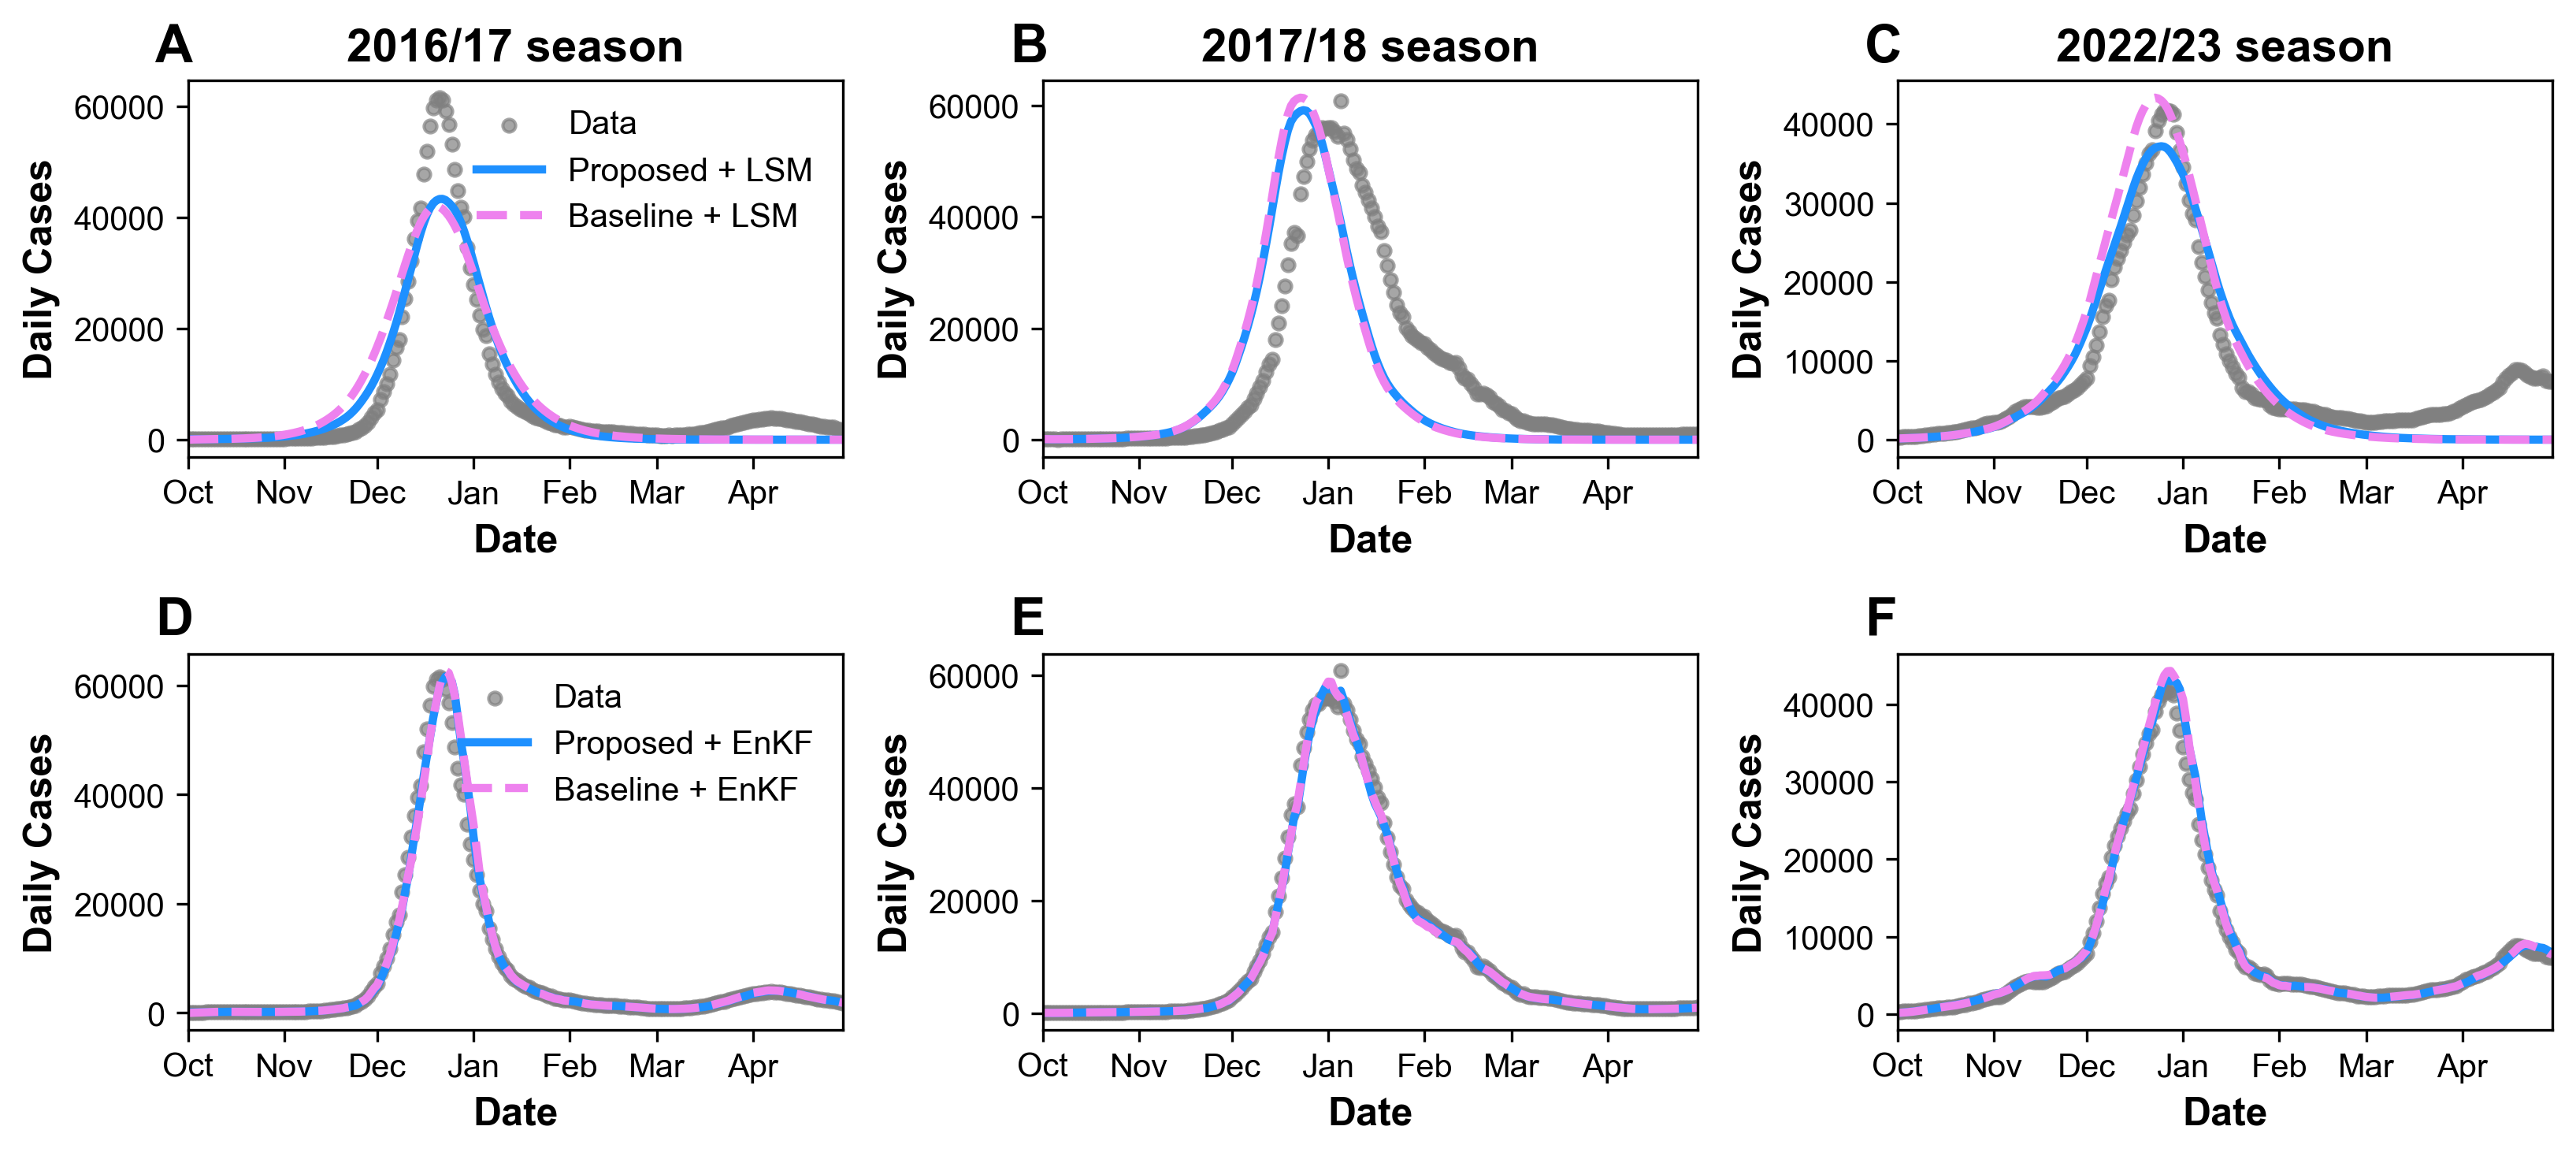

In [6]:
# --- Combined LSM + EnKF time series (2x3) + RMSE barplots (1x2) ---
lsm1617 = pd.read_excel('./Data/Results_1617/EnKF_Detailed_Results.xlsx')
lsm1718 = pd.read_excel('./Data/Results_1718/EnKF_Detailed_Results.xlsx')
lsm2223 = pd.read_excel('./Data/Results_2223/EnKF_Detailed_Results.xlsx')

for df in (lsm1617, lsm1718, lsm2223):
    df['Date'] = pd.to_datetime(df['Date'])

season_labels = ['2016/17 season', '2017/18 season', '2022/23 season']
lsm_list = [lsm1617, lsm1718, lsm2223]
fig, axs = plt.subplots(2, 3, figsize=(11, 5), dpi=300)

for i, (ax, df, season) in enumerate(zip(axs[0], lsm_list, season_labels)):
    ax.scatter(df['Date'], df['Observed'], color='gray', s=15, alpha=0.7, label='Data')
    ax.plot(df['Date'], df['LSM_Combo'], color='dodgerblue', linewidth=2.5, label='Proposed + LSM')
    ax.plot(df['Date'], df['LSM_ah'], color='violet', linewidth=2.5, label='Baseline + LSM', linestyle = '--')
    ax.set_title(f"{season}", fontweight='bold', fontsize=14)
    ax.set_ylabel('Daily Cases', fontweight='bold', fontsize=12)
    ax.set_xlabel('Date', fontweight='bold', fontsize=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_xlim(df['Date'].min(), df['Date'].max())
    if i == 0:
        ax.legend(frameon=False, fontsize=10)
    ax.text(-0.05, 1.05, chr(ord('A') + i), transform=ax.transAxes, fontsize=16, fontweight='bold')

for i, (ax, df, season) in enumerate(zip(axs[1], lsm_list, season_labels)):
    ax.scatter(df['Date'], df['Observed'], color='gray', s=15, alpha=0.7, label='Data')
    ax.plot(df['Date'], df['EnKF_Combo'], color='dodgerblue', linewidth=2.5, label='Proposed + EnKF')
    ax.plot(df['Date'], df['EnKF_AH'], color='violet', linewidth=2.5, label='Baseline + EnKF', linestyle = '--')
    ax.set_ylabel('Daily Cases', fontweight='bold', fontsize=12)
    ax.set_xlabel('Date', fontweight='bold', fontsize=12)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
    ax.set_xlim(df['Date'].min(), df['Date'].max())
    if i == 0:
        ax.legend(frameon=False, fontsize=10, loc = 'upper right')
    ax.text(-0.05, 1.05, chr(ord('D') + i), transform=ax.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
fig.savefig(os.path.join(fig_dir, 'Figure 2.png'), dpi=set_dpi)
plt.show()

# Figure 3

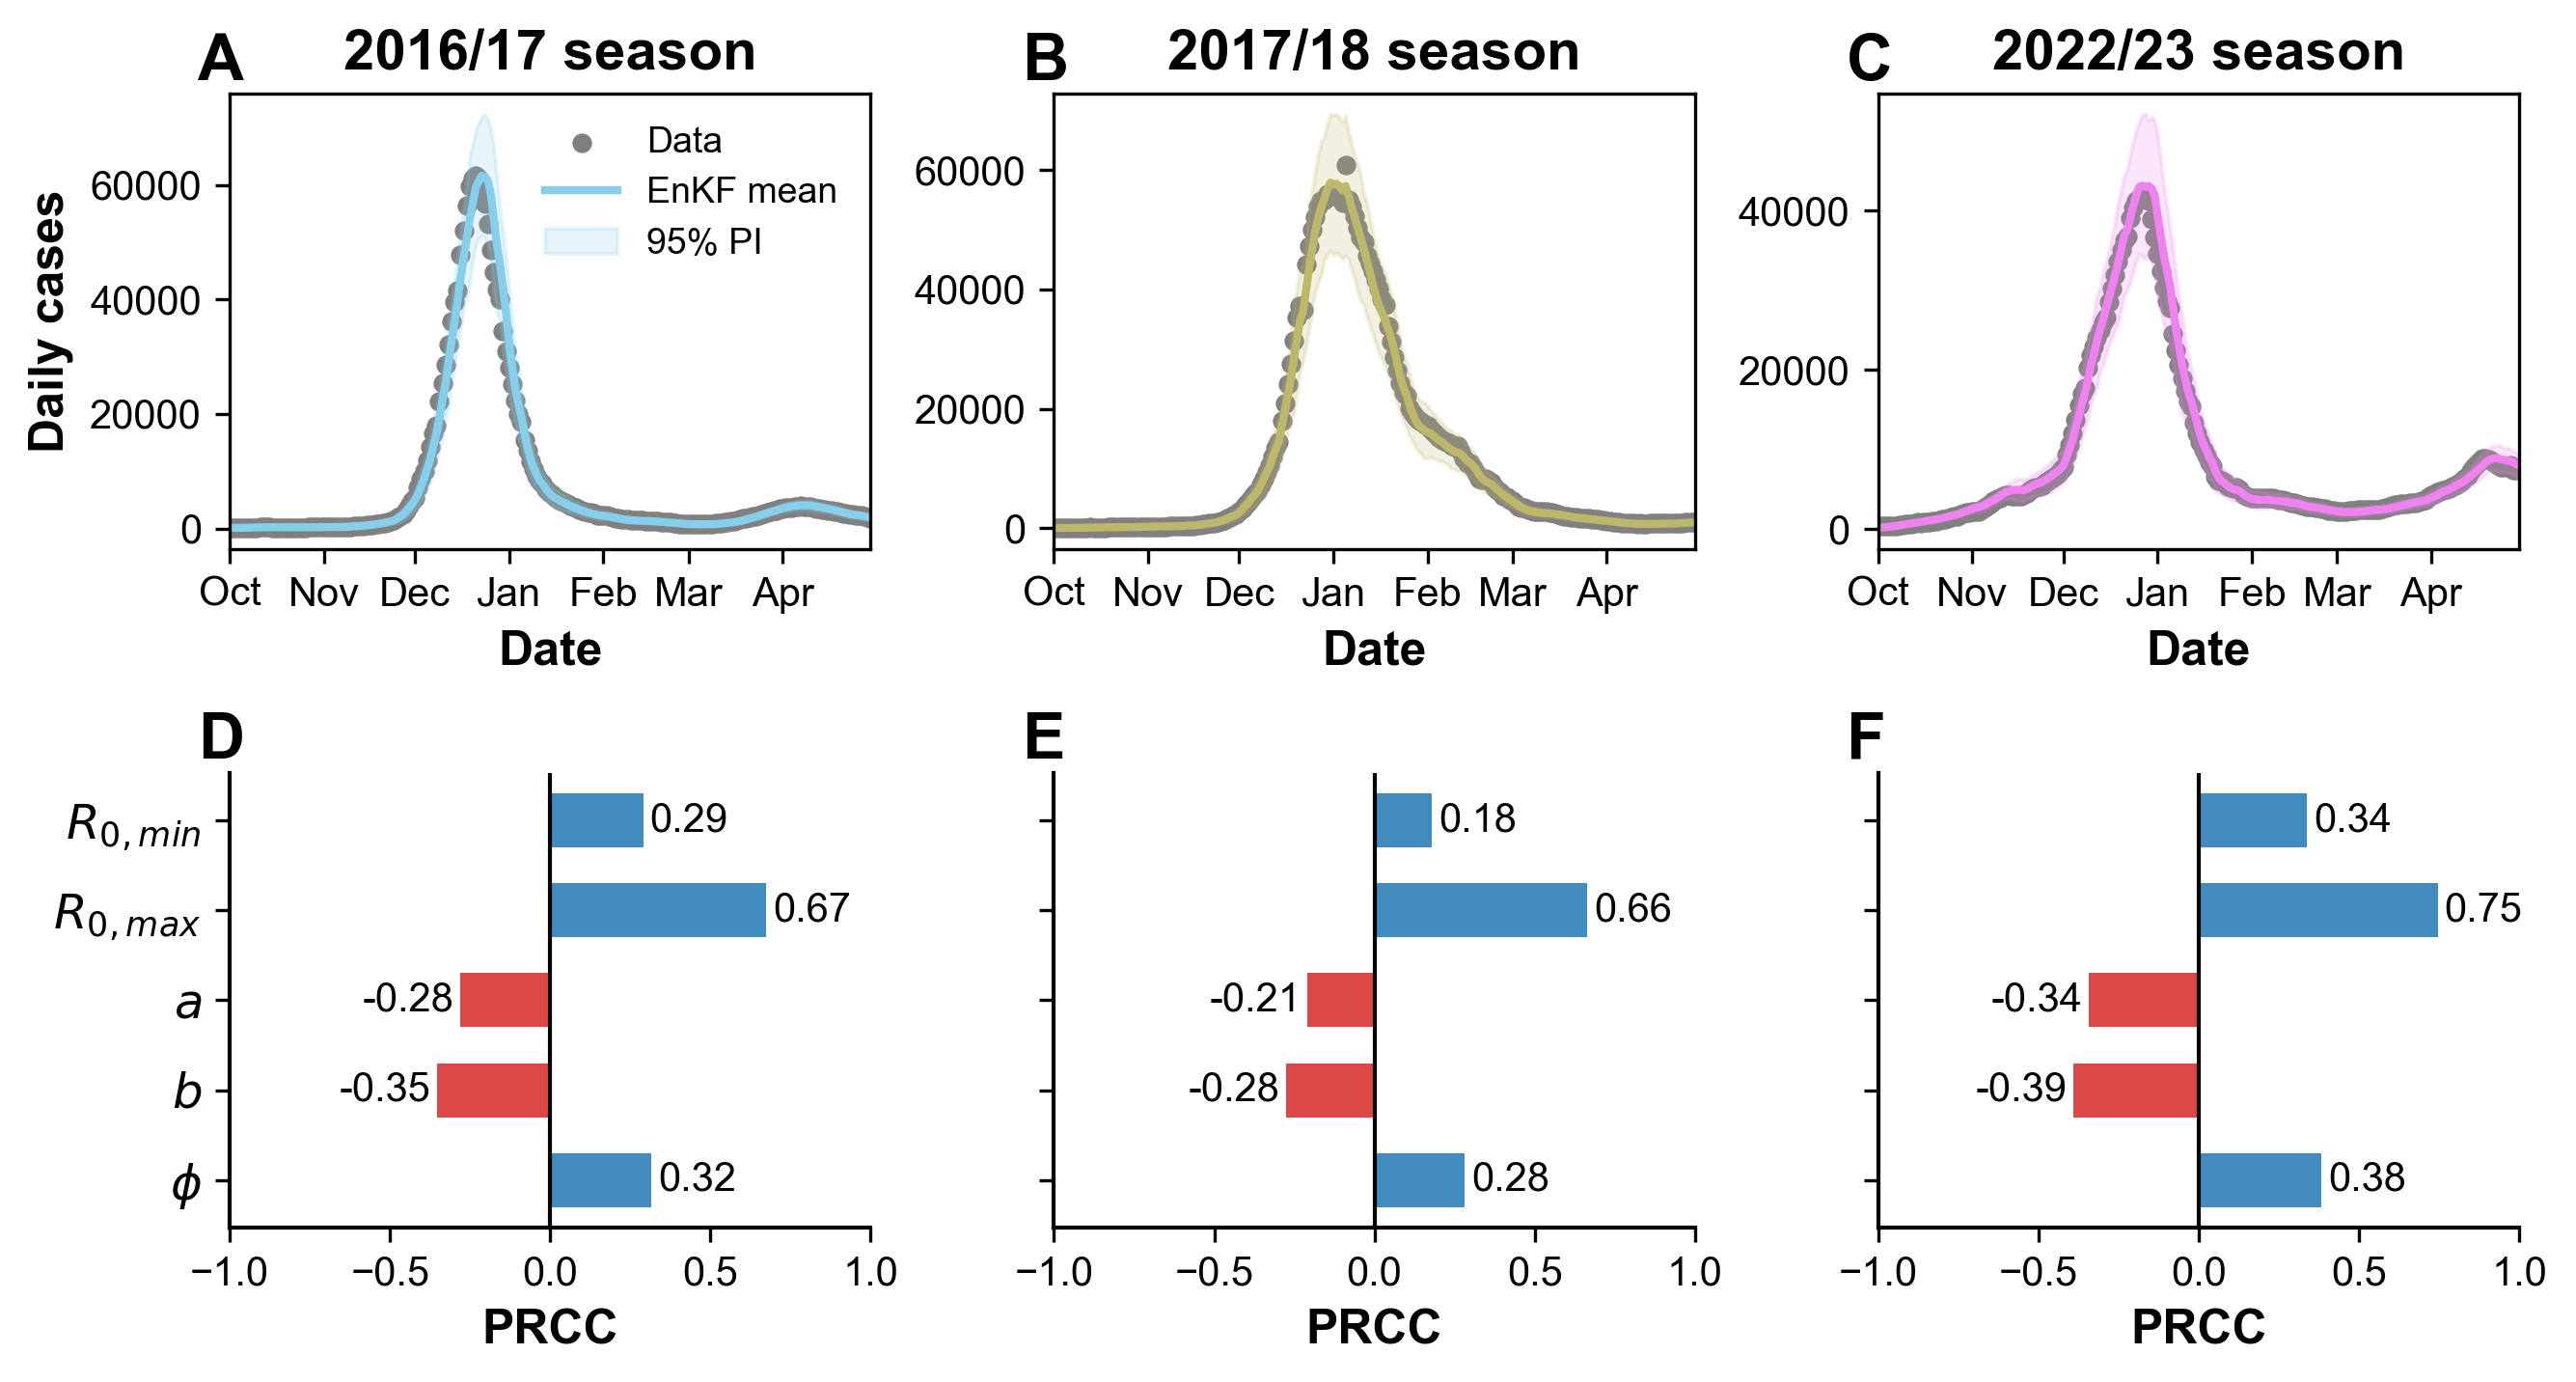

In [7]:
if EnKF_1617_smooth is not None and EnKF_1718_smooth is not None and EnKF_2223_smooth is not None:
    fig, axs = plt.subplots(2, 3, figsize=(9, 5), dpi=300)

    season_labels = ['16/17 season', '17/18 season', '22/23 season']
    season_labels_2 = ['2016/17 season', '2017/18 season', '2022/23 season']
    enkf_data = [EnKF_1617_smooth, EnKF_1718_smooth, EnKF_2223_smooth]
    prcc_data = {
        '16/17 season': np.array([0.2901, 0.6749, -0.2794, -0.3533, 0.3165]),
        '17/18 season': np.array([0.1794, 0.6646, -0.2099, -0.2750, 0.2825]),
        '22/23 season': np.array([0.3380, 0.7454, -0.3416, -0.3907, 0.3832])
    }
    param_names = [r'$R_{0,min}$', r'$R_{0,max}$', r'$a$', r'$b$', r'$\phi$']
    panel_labels = ['A', 'B', 'C', 'D', 'E', 'F']

    for i in range(3):
        ax = axs[0, i]
        ax.scatter(
            date_list[i],
            enkf_data[i]['data'],
            color='gray',
            s=15,
            label='Data',
        )
        ax.plot(
            date_list[i],
            enkf_data[i]['y_hat'],
            label='EnKF mean',
            color=season_color[i],
            linewidth=2,
        )
        ax.fill_between(
            date_list[i],
            enkf_data[i]['conf_upper_intr_obs'],
            enkf_data[i]['conf_lower_intr_obs'],
            alpha=0.2,
            color=season_color[i],
            label='95% PI',
        )

        ax.set_title(season_labels_2[i], fontweight='bold', fontsize=14)
        ax.set_xlabel('Date', fontweight='bold', fontsize=12)
        if i == 0:
            ax.set_ylabel('Daily cases', fontweight='bold', fontsize=12)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
        ax.set_xlim(date_list[i].min(), date_list[i].max())
        ax.tick_params(axis='x', labelbottom=True)
        if i == 0:
            ax.legend(frameon=False, loc='upper right', fontsize=9)
        ax.text(-0.05, 1.03, panel_labels[i], transform=ax.transAxes, weight='bold', fontsize=16)

    y = np.arange(len(param_names))
    for i, season in enumerate(season_labels):
        ax = axs[1, i]
        values = prcc_data[season]
        colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]
        bars = ax.barh(y, values, color=colors, alpha=0.85, height=0.6)

        ax.set_yticks(y)
        ax.invert_yaxis()
        if i == 0:
            ax.set_yticklabels(param_names, fontsize=12)
            ax.tick_params(axis='y', which='both', left=True, labelleft=True)
        else:
            ax.tick_params(axis='y', which='both', left=True, labelleft=False)

        ax.axvline(0, color='k', linewidth=1)
        ax.set_xlim(-1, 1)
        ax.set_xlabel('PRCC', fontsize=12, fontweight='bold')

        for bar, val in zip(bars, values):
            x = val + (0.02 if val >= 0 else -0.02)
            ha = 'left' if val >= 0 else 'right'
            ax.text(x, bar.get_y() + bar.get_height() / 2, f'{val:.2f}', va='center', ha=ha, fontsize=10)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1)
        ax.spines['bottom'].set_linewidth(1)
        ax.text(-0.05, 1.03, panel_labels[i + 3], transform=ax.transAxes, weight='bold', fontsize=16)

    plt.tight_layout()
    fig.subplots_adjust(top=0.9)
    fig.savefig(os.path.join(fig_dir, 'Figure 3.png'), dpi=set_dpi)
    plt.show()
else:
    print('Skipping combined 2x3 plot: missing EnKF data for one or more seasons.')

# Figure 4

In [8]:
import pandas as pd

# --- 1. Identify relevant columns ---
if EnKF_1617_smooth is not None:
    cols = EnKF_1617_smooth.columns
else:
    cols = []

# Automatically select variables (excluding observed/obs bounds)
var_name = [c for c in cols if (
    (c.startswith('x_hat') or c.startswith('Rt') or 
     c.startswith('conf_lower_intr') or c.startswith('conf_upper_intr'))
    and 'obs' not in c
)]
print('Automatically selected var_name:', var_name)

# --- 2. Helper to rename columns ---
def _rename_cols(df):
    # Total of 22 names expected: 7 params, 1 Rt, 7 lower CI, 7 upper CI
    new_names = [
        'R0min', 'R0max', 'a', 'b', 'phi', 'rho', 'E0', 'Rt',
        'conf_lower_intr_R0min', 'conf_lower_intr_R0max', 'conf_lower_intr_a',
        'conf_lower_intr_b', 'conf_lower_intr_phi', 'conf_lower_intr_rho', 'conf_lower_intr_E0',
        'conf_upper_intr_R0min', 'conf_upper_intr_R0max', 'conf_upper_intr_a',
        'conf_upper_intr_b', 'conf_upper_intr_phi', 'conf_upper_intr_rho', 'conf_upper_intr_E0'
    ]
    
    # Only rename if the column count matches to avoid ValueErrors
    if len(df.columns) == len(new_names):
        df.columns = new_names
    else:
        print(f"Warning: Column mismatch. Expected {len(new_names)}, got {len(df.columns)}")
    return df

# --- 3. Build the table ---
season_map = [
    ('16/17 season', EnKF_1617_smooth),
    ('17/18 season', EnKF_1718_smooth),
    ('22/23 season', EnKF_2223_smooth)
]

# Using a list to collect dataframes (much faster than repetitive pd.concat)
dfs_to_concat = []

for season_label, df in season_map:
    if df is None:
        continue
        
    for region in region_name:
        # Extract data for the specific region and variables
        if region in df.columns:
            tmp = df[region][var_name].copy()
        else:
            # Fallback if the dataframe isn't multi-indexed by region
            tmp = df[var_name].copy()
            
        # Apply the renaming and metadata
        tmp = _rename_cols(tmp)
        tmp['Region'] = region
        tmp['Season'] = season_label
        
        dfs_to_concat.append(tmp)

# Final concatenation
if dfs_to_concat:
    est_param2 = pd.concat(dfs_to_concat, axis=0)
    est_param2.reset_index(drop=True, inplace=True)
else:
    est_param2 = pd.DataFrame()

# Display results
est_param2.head()

Automatically selected var_name: ['x_hat_ 5', 'x_hat_ 6', 'x_hat_ 7', 'x_hat_ 8', 'x_hat_ 9', 'x_hat_10', 'x_hat_11', 'Rt', 'conf_lower_intr_ 5', 'conf_lower_intr_ 6', 'conf_lower_intr_ 7', 'conf_lower_intr_ 8', 'conf_lower_intr_ 9', 'conf_lower_intr_10', 'conf_lower_intr_11', 'conf_upper_intr_ 5', 'conf_upper_intr_ 6', 'conf_upper_intr_ 7', 'conf_upper_intr_ 8', 'conf_upper_intr_ 9', 'conf_upper_intr_10', 'conf_upper_intr_11']


,R0min,R0max,a,b,phi,rho,E0,Rt,conf_lower_intr_R0min,conf_lower_intr_R0max,...,conf_lower_intr_E0,conf_upper_intr_R0min,conf_upper_intr_R0max,conf_upper_intr_a,conf_upper_intr_b,conf_upper_intr_phi,conf_upper_intr_rho,conf_upper_intr_E0,Region,Season
0,0.100000,2.047046,18.801416,0.304416,1.568391,0.036329,5925.275813,1.268920,0.079717,1.591668,...,4743.888854,0.120283,2.502423,22.736419,0.363002,1.898444,0.043572,7106.662773,Korea,16/17 season
1,0.099051,2.061970,19.019540,0.300887,1.578259,0.037556,5935.359742,1.284886,0.078813,1.603871,...,4754.062444,0.119290,2.520070,22.953267,0.359517,1.907491,0.044128,7116.657040,Korea,16/17 season
2,0.099074,2.133509,18.869411,0.298306,1.564315,0.038840,5944.875896,1.356804,0.078832,1.706845,...,4762.867708,0.119315,2.560173,22.800554,0.356627,1.895236,0.045163,7126.884084,Korea,16/17 season
3,0.099737,2.197425,18.710915,0.295514,1.539161,0.039798,5962.064437,1.425209,0.079428,1.778952,...,4780.604660,0.120046,2.615898,22.617596,0.353499,1.868022,0.045995,7143.524213,Korea,16/17 season
4,0.100051,2.254172,18.619649,0.293758,1.520683,0.040412,5970.135030,1.487553,0.079752,1.843067,...,4789.511789,0.120350,2.665278,22.502788,0.351952,1.850052,0.046266,7150.758271,Korea,16/17 season


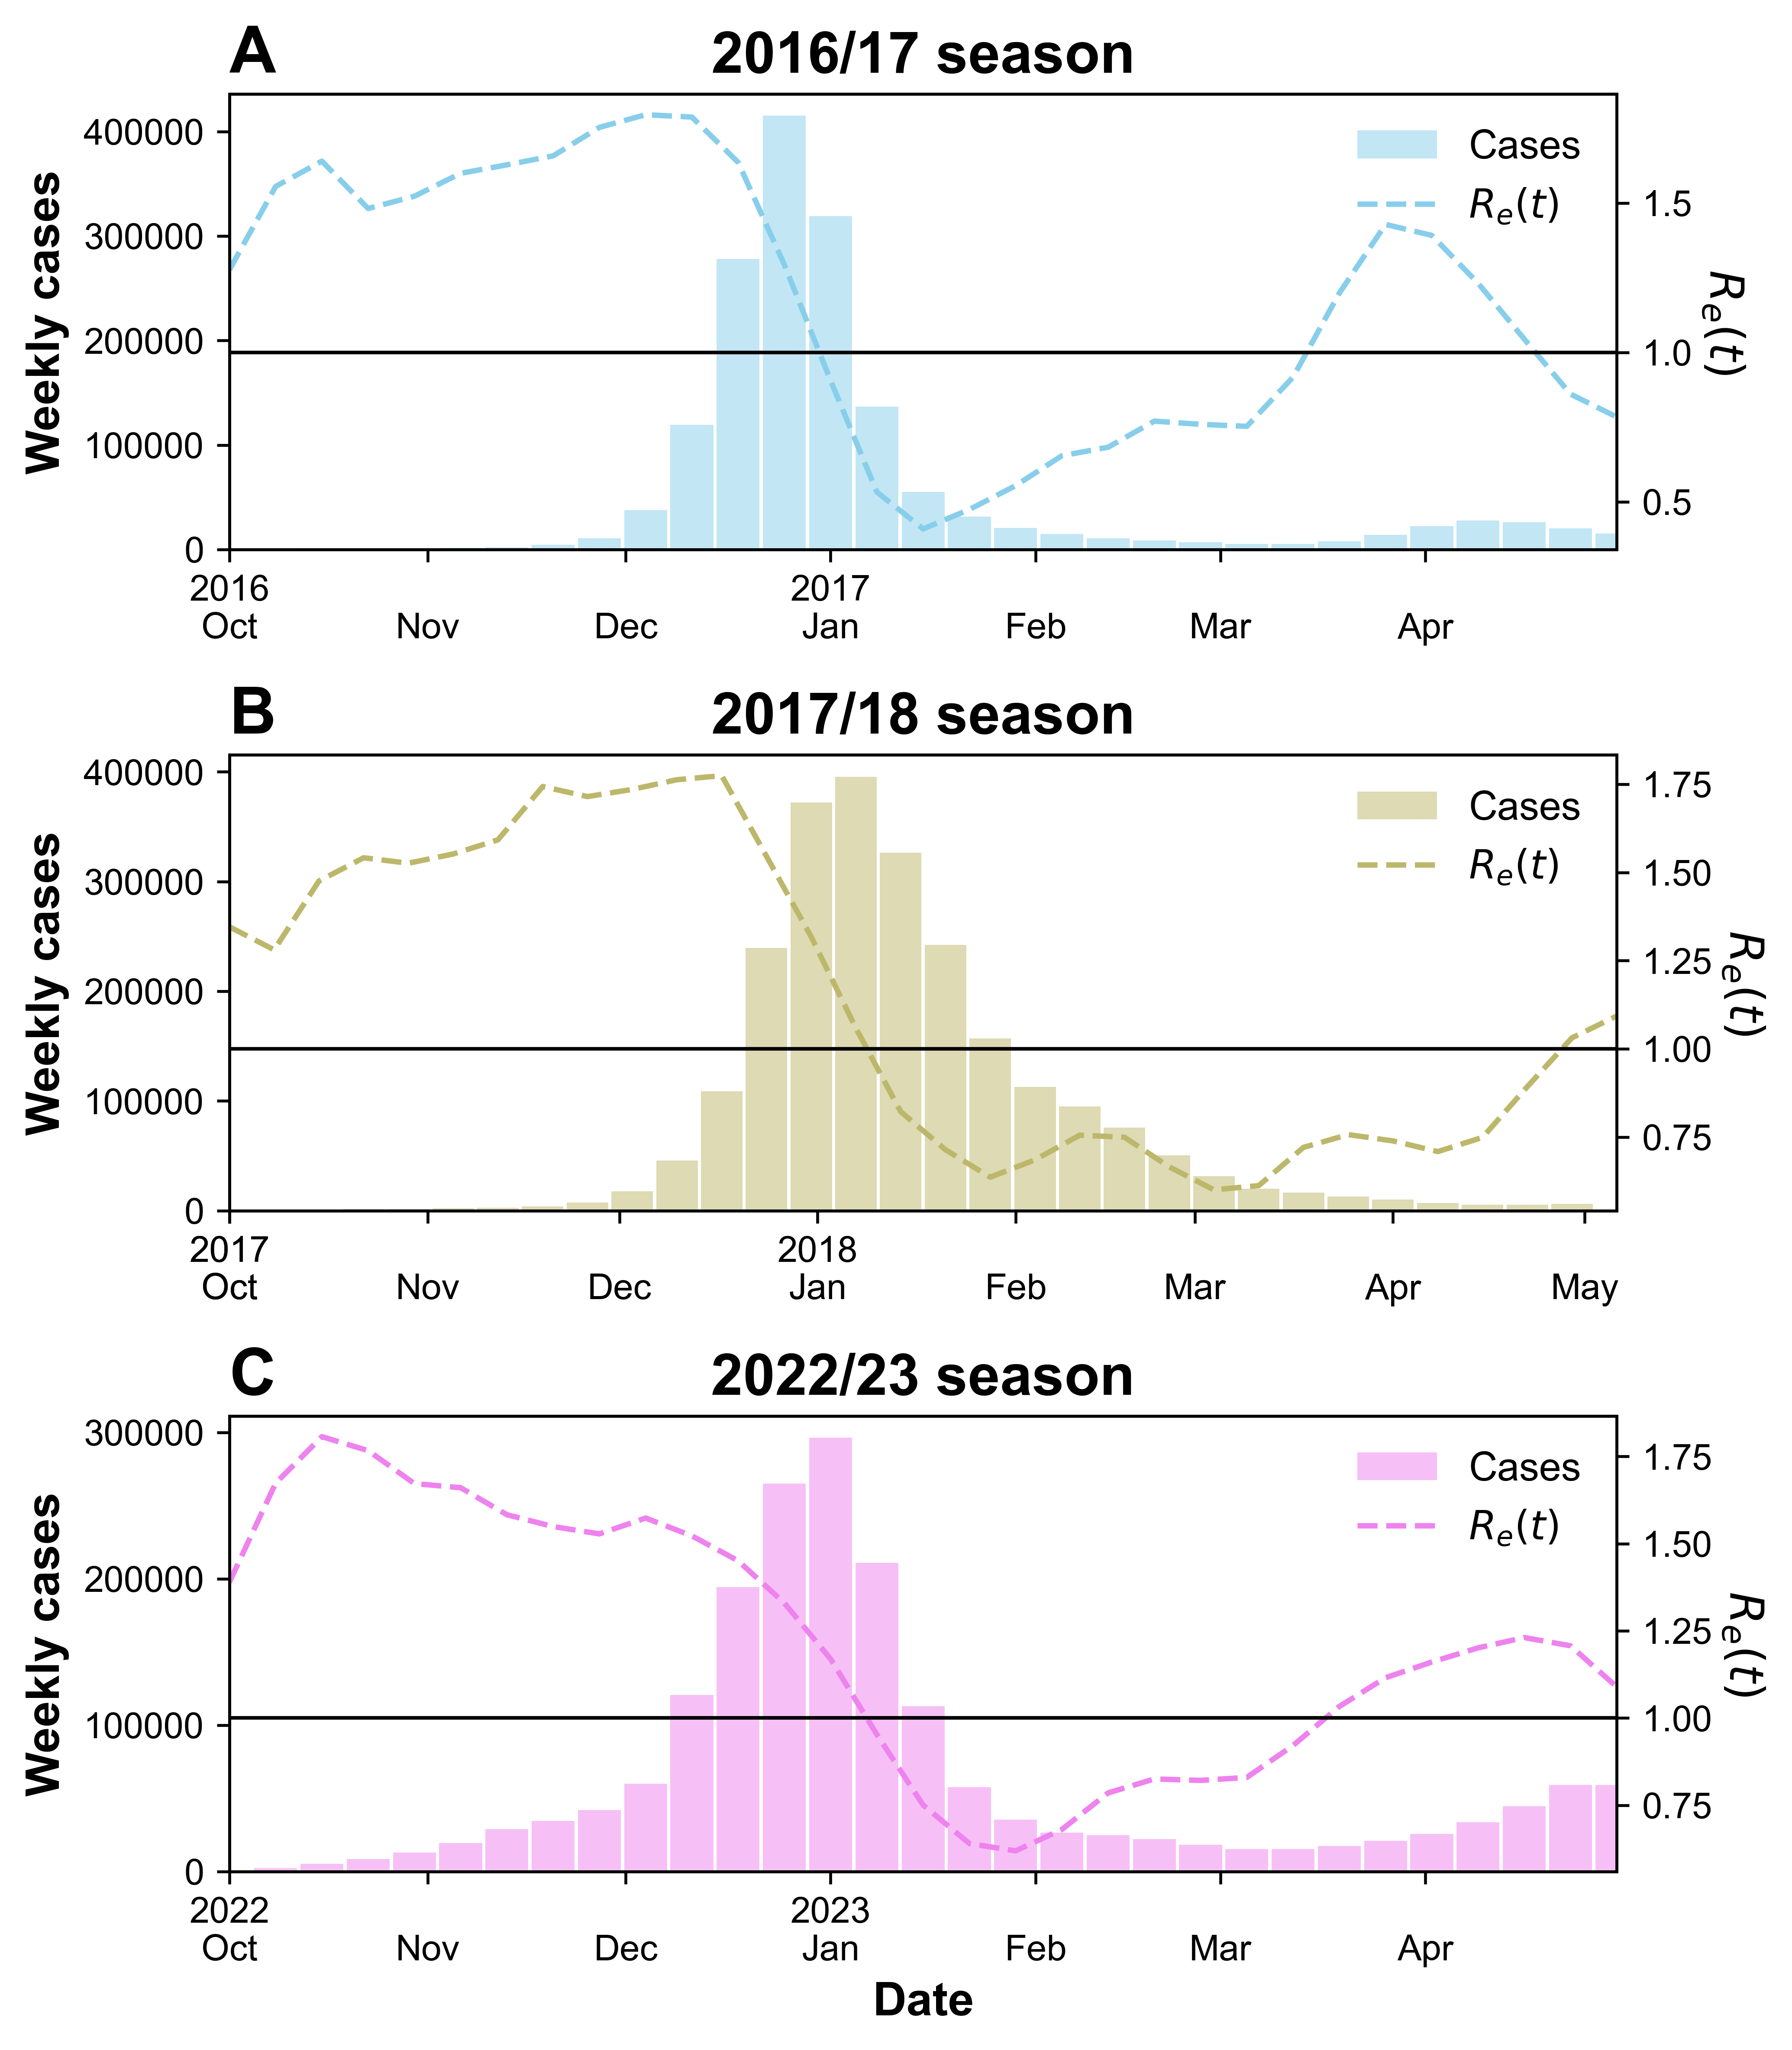

In [9]:
enkf_smooth = [EnKF_1617_smooth, EnKF_1718_smooth, EnKF_2223_smooth]

fig, axs = plt.subplots(3, 1, figsize=(7, 8), dpi=set_dpi, sharex=False)

for i, (df, dates, season_label) in enumerate(zip(enkf_smooth, date_list, season_labels)):
    ax = axs[i]

    if df is None:
        print(f"Skipping Re(t) plot for {season_label}: missing EnKF data")
        continue

    # Weekly cases (from y_hat)
    tmp = df[['y_hat']].copy()
    tmp.loc[:, 'Date'] = dates
    Case = tmp.set_index('Date').resample('W').sum().reset_index()

    ax.bar(
        Case['Date'],
        Case['y_hat'],
        label='Cases',
        color=season_color[i],
        linewidth=2,
        width=6.5,
        alpha=0.5,
    )
    ax.set_title(season_labels_2[i], fontweight='bold', fontsize=16)
    ax.set_ylabel('Weekly cases', fontweight='bold', fontsize=13)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_xlim(Case['Date'].iloc[0], Case['Date'].iloc[-1])

    # Weekly Re(t)
    ax0 = ax.twinx()
    tmp2 = df[['Rt']].copy()
    tmp2.loc[:, 'Date'] = dates
    R0 = tmp2.set_index('Date').resample('W').mean().reset_index()

    ax0.plot(
        R0['Date'],
        R0['Rt'],
        color=season_color[i],
        linewidth=1.5,
        linestyle='--',
        label=r'$R_e(t)$',
    )
    ax0.axhline(y=1, color='k', linestyle='-', linewidth=1)
    ax0.set_ylabel(r'$R_e(t)$', fontsize=13, rotation=270, labelpad=15)
    handles, labels = ax.get_legend_handles_labels()
    handles2, labels2 = ax0.get_legend_handles_labels()
    ax.legend(handles + handles2, labels + labels2, loc='upper right', fontsize=11, frameon=False)

    # Delay between peak cases and peak Re
    delay_weeks = np.argmax(Case['y_hat']) - np.argmax(R0['Rt'])
    ax.text(0, 1.15, string.ascii_uppercase[i], transform=ax.transAxes, weight='bold', fontsize=18, va='top')

    dates = R0['Date']
    first_month_per_year = (
        dates
        .groupby(dates.dt.year)
        .min()
        .dt.month
    )
    first_month_dict = first_month_per_year.to_dict()
    ticks = mdates.MonthLocator(interval=1).tick_values(dates.min(), dates.max())  # type: ignore[arg-type]
    ticks = np.concatenate(([mdates.date2num(dates.min())], ticks))
    ax.set_xticks(ticks)

    def make_formatter(first_month_dict):
        def year_month_formatter(x, pos=None):
            dt = mdates.num2date(x)
            year = dt.year
            month = dt.month
            if month == first_month_dict.get(year, None):
                return f"{year}\n{dt.strftime('%b')}"
            else:
                return dt.strftime('\n%b')
        return year_month_formatter
    ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(first_month_dict)))
# Shared label and layout tweaks
axs[-1].set_xlabel('Date', fontweight='bold', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "Figure 4.png"), dpi=set_dpi)
plt.show()

# Figure 5

In [10]:
pos_list = [pos_1617, pos_1718, pos_2223]
title_list = ['2016/17 season', '2017/18 season', '2022/23 season']

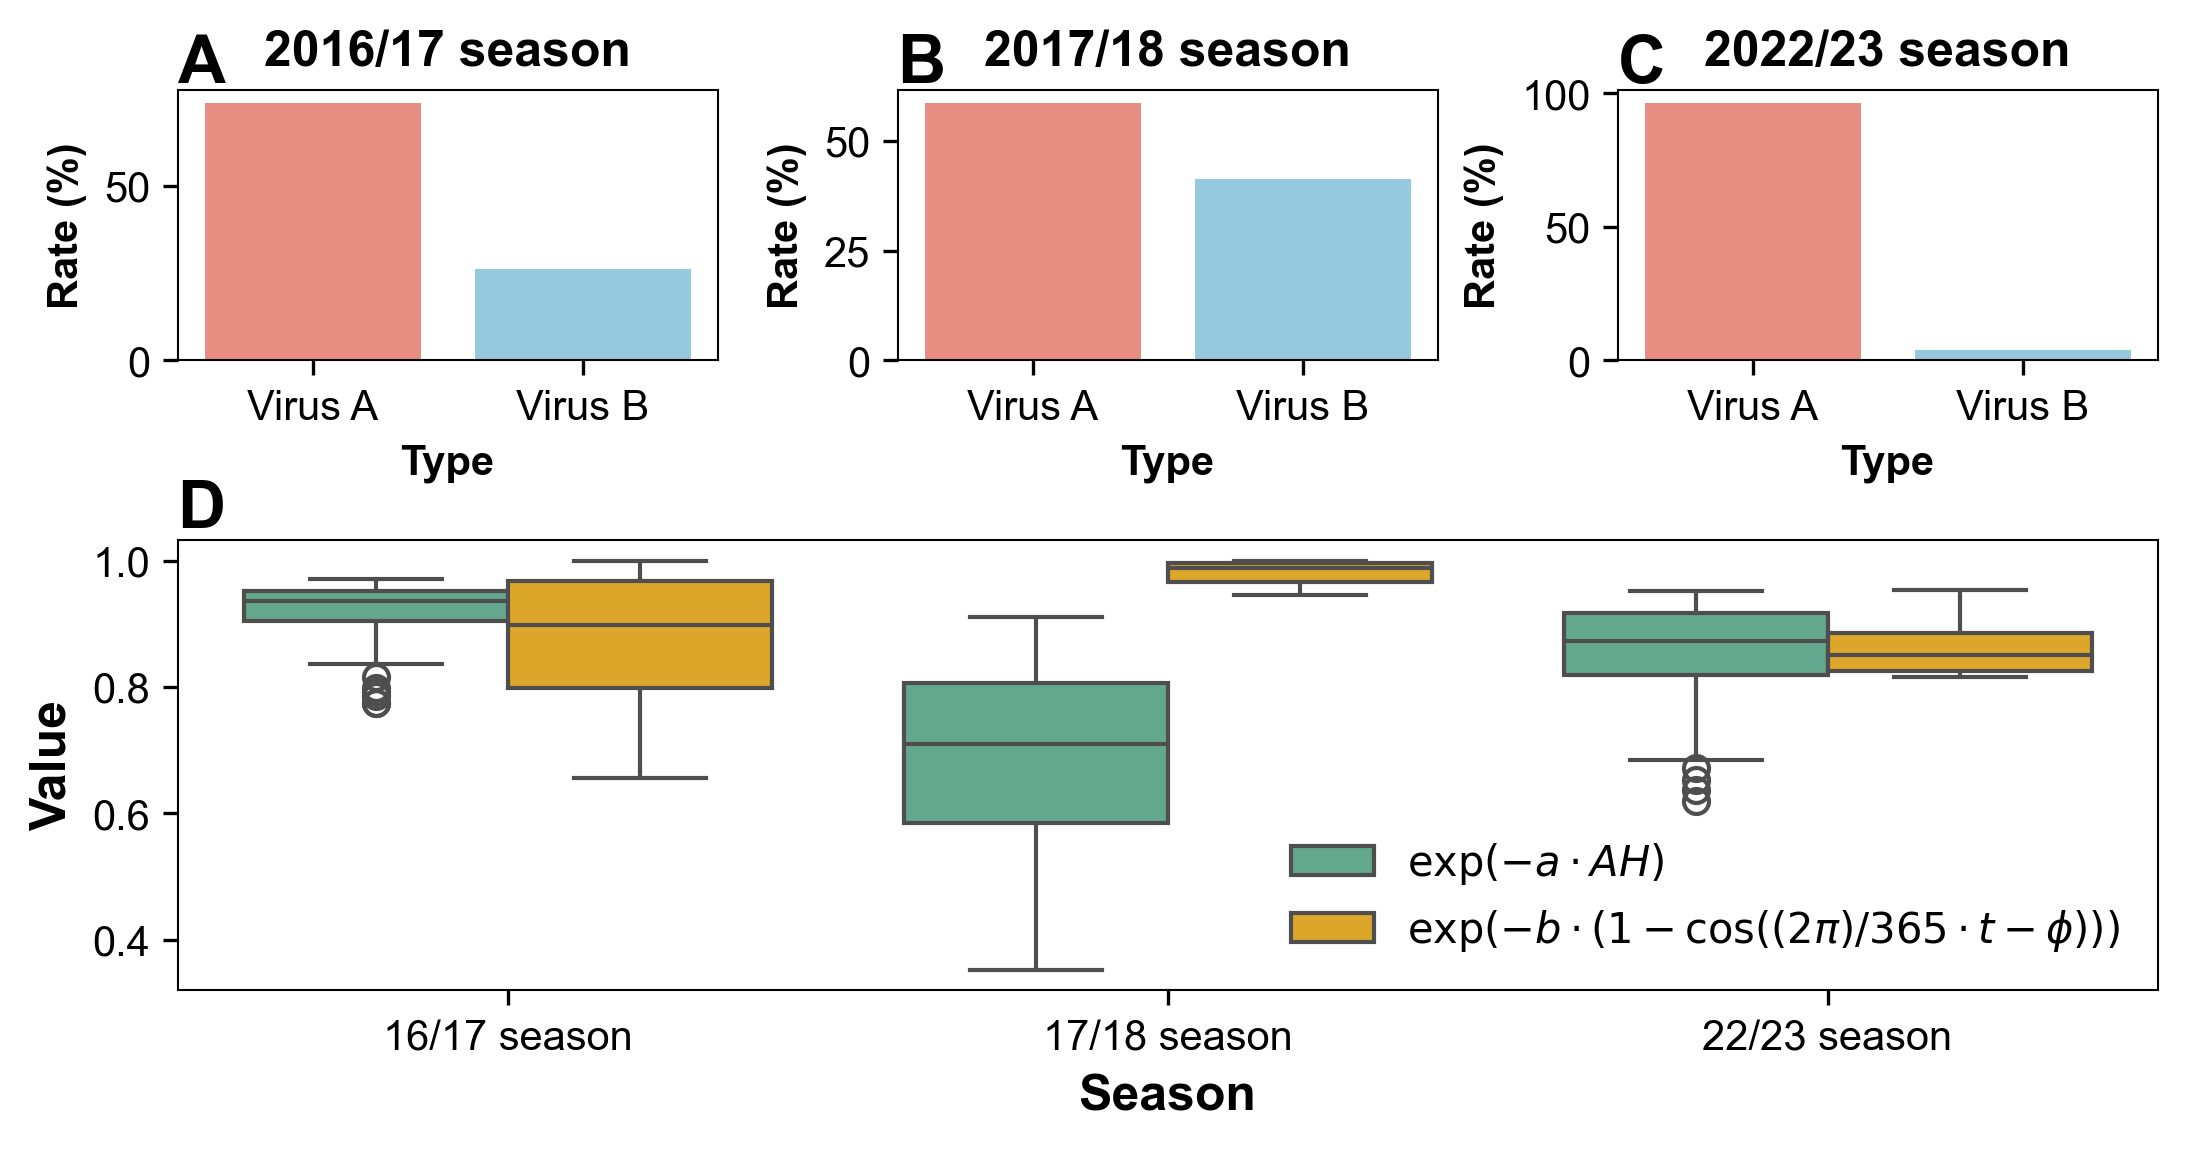

In [11]:
import seaborn as sns

fig = plt.figure(figsize=(6, 3), dpi = 300)

ax_list = [fig.add_gridspec(nrows=1,ncols=1,top=1, bottom=0.7,left=0, right=0.3),
           fig.add_gridspec(nrows=1,ncols=1,top=1, bottom=0.7, left=0.4, right=0.7),
           fig.add_gridspec(nrows=1,ncols=1,top=1, bottom=0.7, left=0.8, right=1.1),
           fig.add_gridspec(nrows=1,ncols=1,top=0.5, bottom=0,left=0, right=1.1)]

for i, axes in enumerate(ax_list):
    ax = fig.add_subplot(axes[0])
    ax.grid(False)
    ax.tick_params(axis='y', pad=3)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
    ax.text(0, 1.03, string.ascii_uppercase[i], transform=ax.transAxes, weight='bold', fontsize=16)
    
    if i < 3:
        tmp = pos_list[i].rename(columns={'A_rate':'Virus A', 'B_rate':'Virus B'})
        tmp = tmp.set_index('date').unstack().reset_index()
        tmp.rename(columns={'level_0':'Type', 0:'Rate(%)', 'date':'Date'}, inplace=True)
        sns.barplot(x = 'Type', y= 'Rate(%)', data = tmp,  palette=['salmon', 'skyblue'], errorbar=None)
        ax.set_xlabel('Type', fontweight='bold')
        ax.set_ylabel('Rate (%)', fontweight='bold')
        ax.set_title(title_list[i], fontweight='bold')
    else:
        enkf_smooth = [EnKF_1617_smooth, EnKF_1718_smooth, EnKF_2223_smooth]

        AHs = []
        PHIs = []
        for k, season in enumerate(season_labels):
            es_k = enkf_smooth[k]
            if es_k is None: continue
            tmp = est_param2[(est_param2['Region'] == 'Korea') & (est_param2['Season'] == season)]
            aAH = np.exp(-tmp['a'].to_numpy()*es_k['AH'].to_numpy())
            AHs.append(aAH)

            t = tmp.index.values
            bphi = np.exp(-tmp['b'].to_numpy()*(1-np.cos((2*np.pi)/365*t - tmp['phi'].to_numpy())))
            PHIs.append(bphi)

        tmp_data = []
        for i, season in enumerate(season_labels):
            for v in AHs[i]:
                tmp_data.append([season, v, f'$\\exp(-a \\cdot AH)$'])
            for v in PHIs[i]:
                tmp_data.append([season, v, f'$\\exp(-b \\cdot (1-\\cos((2\\pi)/365 \\cdot t - \\phi)))$'])

        aAH_bPHI = pd.DataFrame(tmp_data, columns=['Season', 'Value', 'Type'])
        sns.boxplot(x='Season', y='Value', hue='Type', data=aAH_bPHI, ax=ax, palette=['#59B292', "#F8B20D"])
        ax.set_xlabel('Season', fontsize = 12, fontweight='bold')
        ax.set_ylabel('Value', fontsize = 12, fontweight='bold')
        plt.legend(frameon=False, fontsize=10)

plt.savefig(os.path.join(fig_dir, 'Figure 5.png'), dpi=set_dpi, bbox_inches='tight')
plt.show()